<a href="https://colab.research.google.com/github/hoin1357/BigDataPrograming_task/blob/main/titanic_analysis2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 타이타닉 생존자 분석
## 데이터분석 프로그래밍 팀 과제 1

**핵심 질문: 누가 살아남았는가? 그리고 그 이유는?**

---

### 분석 흐름
1. 데이터 로드 & 개요
2. 결측치 처리 및 파생 변수 생성
3. EDA (탐색적 데이터 분석)
4. 결론 및 인사이트

## 0. Colab 환경 설정 (한글 폰트)

In [1]:
# Colab에서 한글 폰트 설치 (최초 1회 실행 후 런타임 재시작 필요)
!sudo apt-get install -y fonts-nanum > /dev/null
!sudo fc-cache -fv > /dev/null
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import os

# 나눔 폰트 명시적 등록 (Colab 한글 깨짐 방지)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False
    print('한글 폰트 설정 완료:', font_name)
else:
    print('나눔 폰트 미설치. 위 셀 실행 후 런타임 재시작 필요')

한글 폰트 설정 완료: NanumGothic


## 1. 라이브러리 & 데이터 로드

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid', {'font.family': 'NanumGothic'})
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# Colab: 파일 업로드
from google.colab import files
uploaded = files.upload()  # titanic.csv 선택

df = pd.read_csv('titanic.csv', index_col=0)
print('데이터 크기:', df.shape)
df.head()

Saving titanic.csv to titanic.csv
데이터 크기: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 2. 데이터 개요

- 전체 1,309명 승객 데이터
- 타겟 변수: `survived` (0=사망, 1=생존)
- 모든 컬럼명은 소문자
- 새 컬럼: `boat`(구명보트 번호), `body`(시신 식별번호), `home.dest`(목적지)

In [5]:
print('--- 컬럼 타입 ---')
print(df.dtypes)
print('\n--- 결측치 ---')
print(df.isnull().sum())
print('\n--- 생존 분포 ---')
print(df['survived'].value_counts(normalize=True).round(3))

--- 컬럼 타입 ---
pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

--- 결측치 ---
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

--- 생존 분포 ---
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pclass,1309.0,NaN,NaN,NaN,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
survived,1309.0,NaN,NaN,NaN,0.381971,0.486055,0.0,0.0,0.0,1.0,1.0
name,1309,1307,"Kelly, Mr. James",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1309,2,male,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1046.0,NaN,NaN,NaN,29.881135,14.4135,0.1667,21.0,28.0,39.0,80.0
sibsp,1309.0,NaN,NaN,NaN,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
parch,1309.0,NaN,NaN,NaN,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
ticket,1309,929,CA. 2343,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,1308.0,NaN,NaN,NaN,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292
cabin,295,186,C23 C25 C27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**주요 발견**
- 생존율 약 **38%** — 사망자가 더 많음
- `age` 결측 약 263개, `cabin` 결측 1,014개, `body` 결측 1,188개(생존자는 시신 없음), `boat` 결측 823개(사망자는 보트 안 탐)
- `boat`, `body`는 생존 여부와 거의 동일한 정보 → 분석 변수에서 제외 (사후정보 leakage)

## 3. 결측치 처리 & 파생 변수 생성

In [7]:
# 3-1) name에서 title(호칭) 추출
df['title'] = df['name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 희귀 호칭 통합
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
}
df['title'] = df['title'].map(title_map).fillna('Rare')

print(df['title'].value_counts())

title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


In [8]:
# 3-2) age 결측치: title별 중앙값으로 채우기
df['age'] = df.groupby('title')['age'].transform(lambda x: x.fillna(x.median()))

# 3-3) fare 결측치: pclass별 중앙값
df['fare'] = df.groupby('pclass')['fare'].transform(lambda x: x.fillna(x.median()))

# 3-4) embarked 결측치: 최빈값(S)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 3-5) cabin → deck(첫 글자), 결측은 'U'(Unknown)
df['deck'] = df['cabin'].astype(str).str[0]
df['deck'] = df['deck'].replace('n', 'U')  # NaN→'n'이므로 U로

# 3-6) 파생 변수
df['family_size'] = df['sibsp'] + df['parch'] + 1   # 본인 포함
df['is_alone']    = (df['family_size'] == 1).astype(int)
df['age_group']   = pd.cut(df['age'],
                           bins=[0, 12, 18, 35, 60, 100],
                           labels=['아동', '청소년', '청년', '중년', '노년'])
df['fare_group']  = pd.qcut(df['fare'], q=4, labels=['저', '중하', '중상', '고'])

# 3-7) 사후정보(leakage) 컬럼 분석에서 제외
df_analysis = df.drop(columns=['boat', 'body', 'home.dest', 'ticket', 'cabin', 'name'])

print('결측치 처리 후:')
print(df_analysis.isnull().sum())

결측치 처리 후:
pclass         0
survived       0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
title          0
deck           0
family_size    0
is_alone       0
age_group      0
fare_group     0
dtype: int64


## 4. EDA — 누가 살아남았는가?

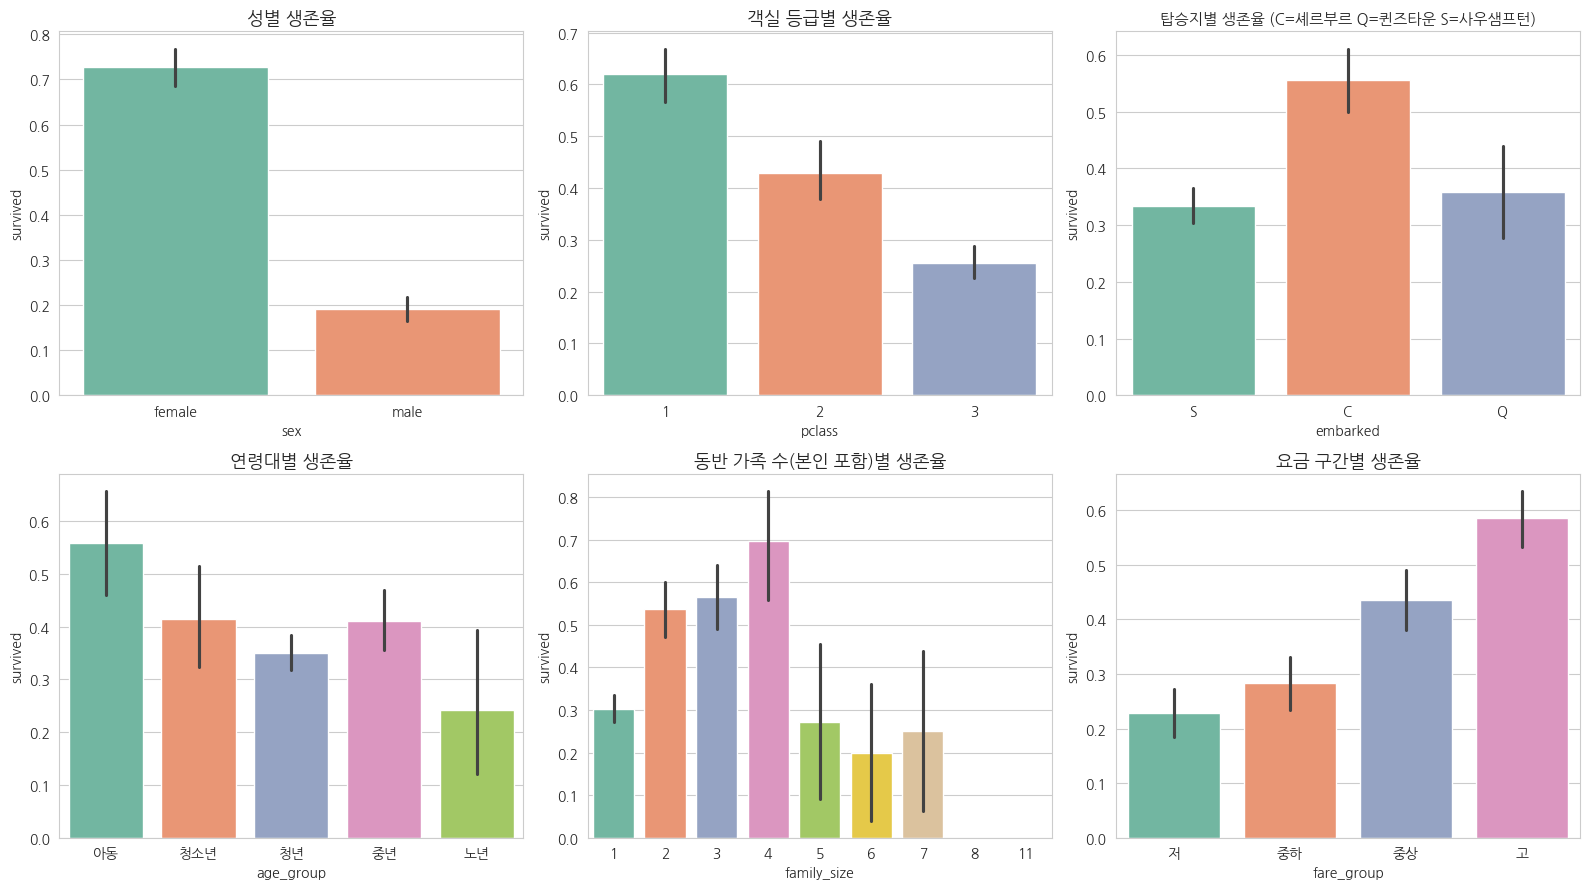

In [9]:
# 4-1) 핵심 변수 6개 동시 비교
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.barplot(data=df_analysis, x='sex', y='survived', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('성별 생존율', fontsize=13)

sns.barplot(data=df_analysis, x='pclass', y='survived', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('객실 등급별 생존율', fontsize=13)

sns.barplot(data=df_analysis, x='embarked', y='survived', ax=axes[0,2], palette='Set2')
axes[0,2].set_title('탑승지별 생존율 (C=셰르부르 Q=퀸즈타운 S=사우샘프턴)', fontsize=11)

sns.barplot(data=df_analysis, x='age_group', y='survived', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('연령대별 생존율', fontsize=13)

sns.barplot(data=df_analysis, x='family_size', y='survived', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('동반 가족 수(본인 포함)별 생존율', fontsize=13)

sns.barplot(data=df_analysis, x='fare_group', y='survived', ax=axes[1,2], palette='Set2')
axes[1,2].set_title('요금 구간별 생존율', fontsize=13)

plt.tight_layout()
plt.show()

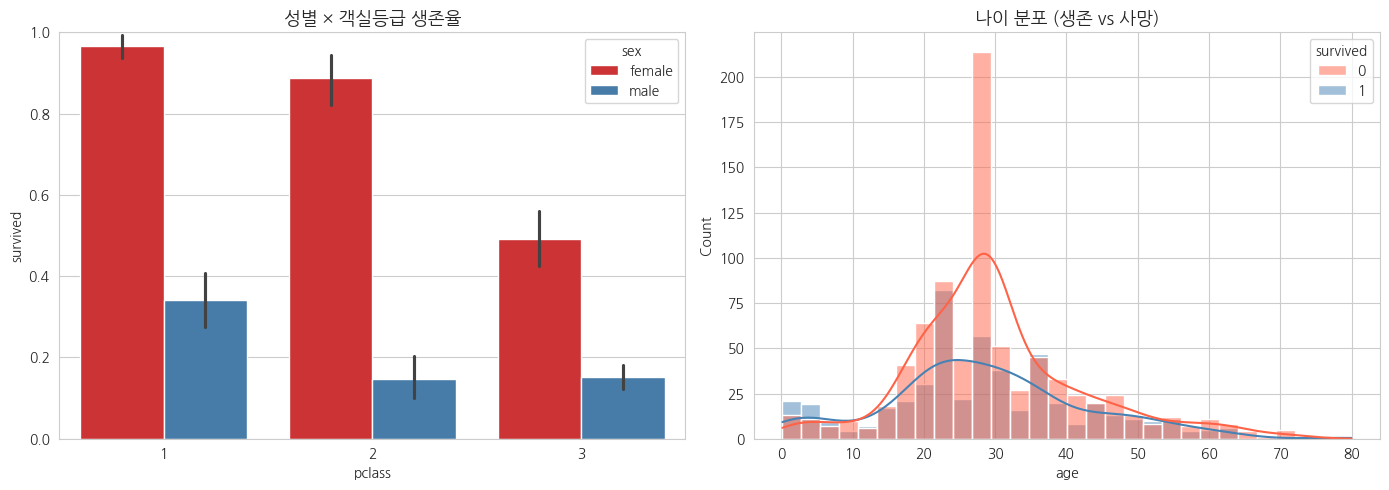

In [10]:
# 4-2) 성별 × 객실등급 교차 (가장 강력한 인사이트)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_analysis, x='pclass', y='survived', hue='sex', ax=axes[0], palette='Set1')
axes[0].set_title('성별 × 객실등급 생존율', fontsize=13)
axes[0].set_ylim(0, 1)

# 나이 분포 (생존/사망)
sns.histplot(data=df_analysis, x='age', hue='survived', bins=30, kde=True,
             ax=axes[1], palette={0:'tomato', 1:'steelblue'})
axes[1].set_title('나이 분포 (생존 vs 사망)', fontsize=13)

plt.tight_layout()
plt.show()

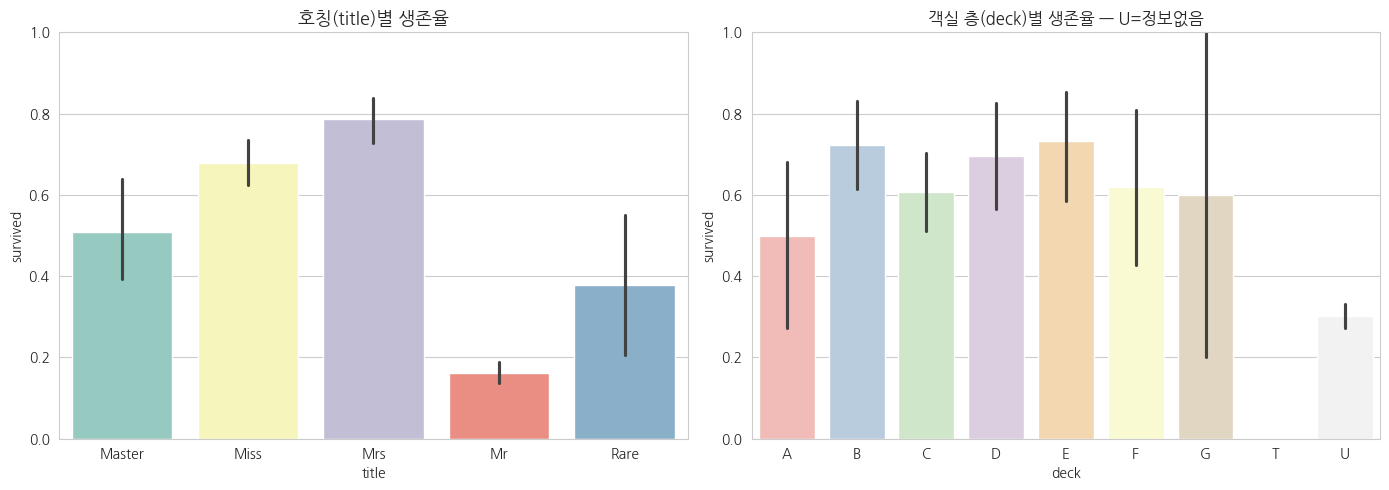

In [11]:
# 4-3) 호칭(title)·층(deck)별 생존율 — 새 데이터셋 컬럼 활용
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

title_order = ['Master', 'Miss', 'Mrs', 'Mr', 'Rare']
sns.barplot(data=df_analysis, x='title', y='survived', order=title_order,
            ax=axes[0], palette='Set3')
axes[0].set_title('호칭(title)별 생존율', fontsize=13)
axes[0].set_ylim(0, 1)

deck_order = ['A','B','C','D','E','F','G','T','U']
sns.barplot(data=df_analysis, x='deck', y='survived', order=deck_order,
            ax=axes[1], palette='Pastel1')
axes[1].set_title('객실 층(deck)별 생존율 — U=정보없음', fontsize=12)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

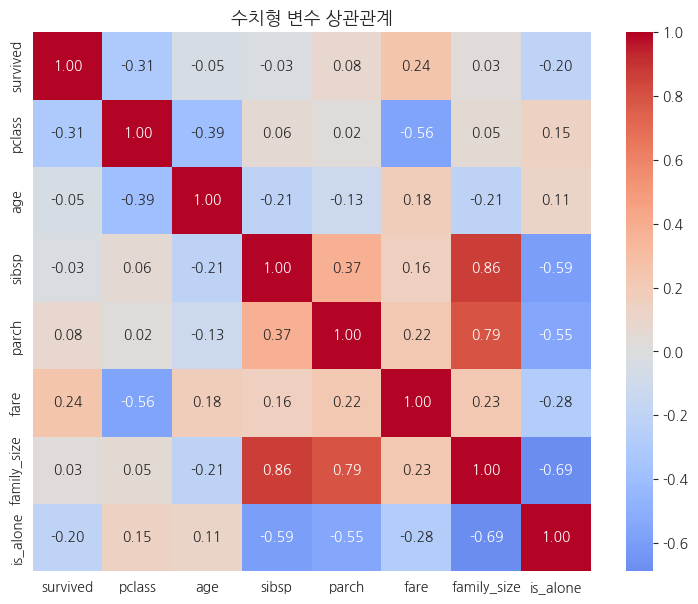

In [12]:
# 4-4) 수치형 변수 상관관계
num_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']
plt.figure(figsize=(9, 7))
sns.heatmap(df_analysis[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('수치형 변수 상관관계', fontsize=13)
plt.show()

### EDA 핵심 인사이트

1. **성별**: 여성 생존율 약 73% vs 남성 약 19% — 가장 큰 격차
2. **객실 등급**: 1등석 62% > 2등석 43% > 3등석 26% — 부유층 우선
3. **호칭**: Master(어린 남자아이) 생존율 높음, Mrs > Miss > Mr 순
4. **나이**: 아동(0~12세) 생존율 높음 — "여성과 어린이 먼저" 원칙 확인
5. **가족 수**: 2~4명 동반 시 가장 높은 생존율, 혼자 또는 대가족은 불리
6. **요금/층**: 비싼 티켓과 상위 층(B,D,E)일수록 생존율 ↑

## 5. 결론 및 인사이트

### 분석 요약
- **가장 큰 격차는 성별** — 여성 73% vs 남성 19% (4배 차이)
- **객실 등급별 격차** — 1등석 62% > 2등석 43% > 3등석 26%
- **성별 × 객실등급 교차 효과** — 1등석 여성 약 97% vs 3등석 남성 약 13%
- **호칭 변수**가 성별·연령·결혼여부를 함께 담은 강력한 변수

### 사회적 시사점
1. **"여성과 어린이 먼저" 원칙은 실제 데이터로 확인됨**
2. **계급 차별 존재** — 구명보트 접근성 차이로 해석
3. **혼자 탑승한 승객은 불리** — 2~4명의 작은 가족 단위가 가장 유리
4. **셰르부르(C) 탑승객 생존율 높음** — 1등석 비율이 높았기 때문

### 한계
- cabin 결측 77% — 객실 위치(층) 정보 활용 제한적
- 표본 1,309명, 단일 사건이라 일반화 주의
- boat/body 같은 사후정보는 분석에서 제외 (생존여부가 거의 그대로 들어있어 의미 없음)